### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [114]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

### Step 2: Load Dataset

In [47]:
df = pd.read_csv('./data/LoanApprovalPrediction.csv')

In [48]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Step 3: Exploaring Data

In [49]:
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,586.000000,598.000000,598.000000,577.000000,584.000000,549.000000
mean,0.755973,5292.252508,1631.499866,144.968804,341.917808,0.843352
std,1.007751,5807.265364,2953.315785,82.704182,65.205994,0.363800
min,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000
50%,0.000000,3806.000000,1211.500000,127.000000,360.000000,1.000000
75%,1.750000,5746.000000,2324.000000,167.000000,360.000000,1.000000
max,3.000000,81000.000000,41667.000000,650.000000,480.000000,1.000000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [80]:
df.isnull().sum()

Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [81]:
df.isna().sum()

Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

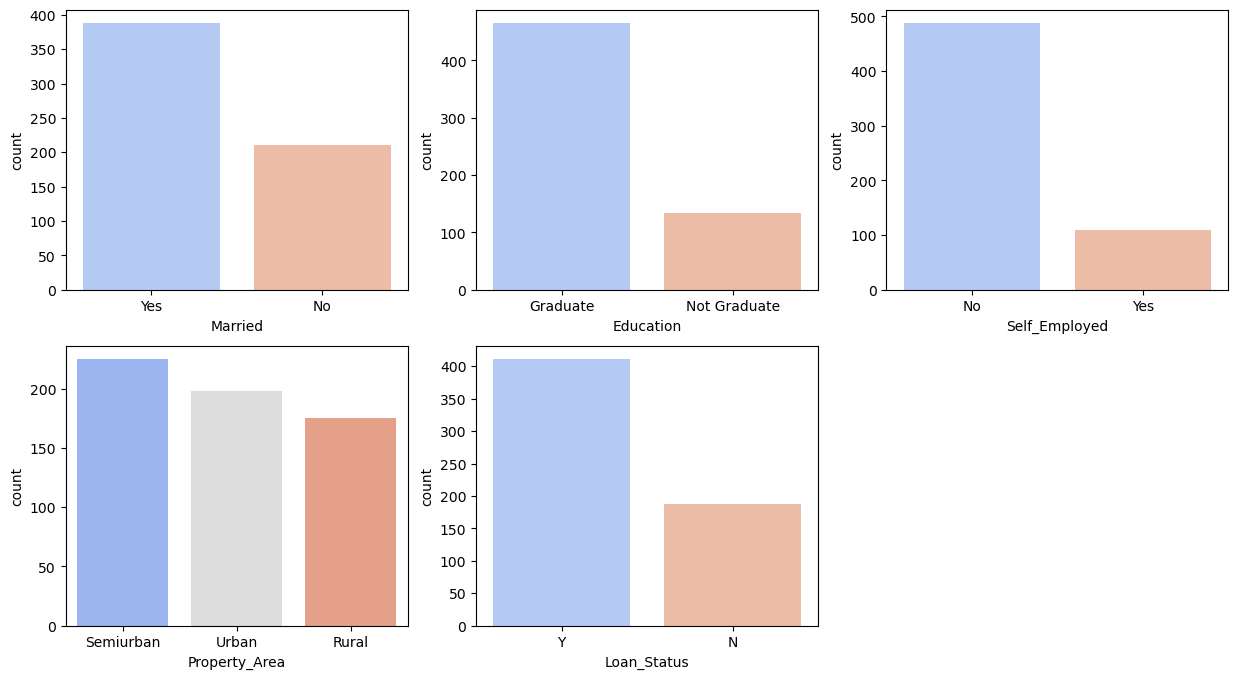

In [65]:
plt.figure(figsize=(15, 8))

for i, obj in enumerate(df.select_dtypes(np.object_).columns):
    if i:
        plt.subplot(2, 3, i)
        sns.barplot(df[obj].value_counts(), palette='coolwarm')

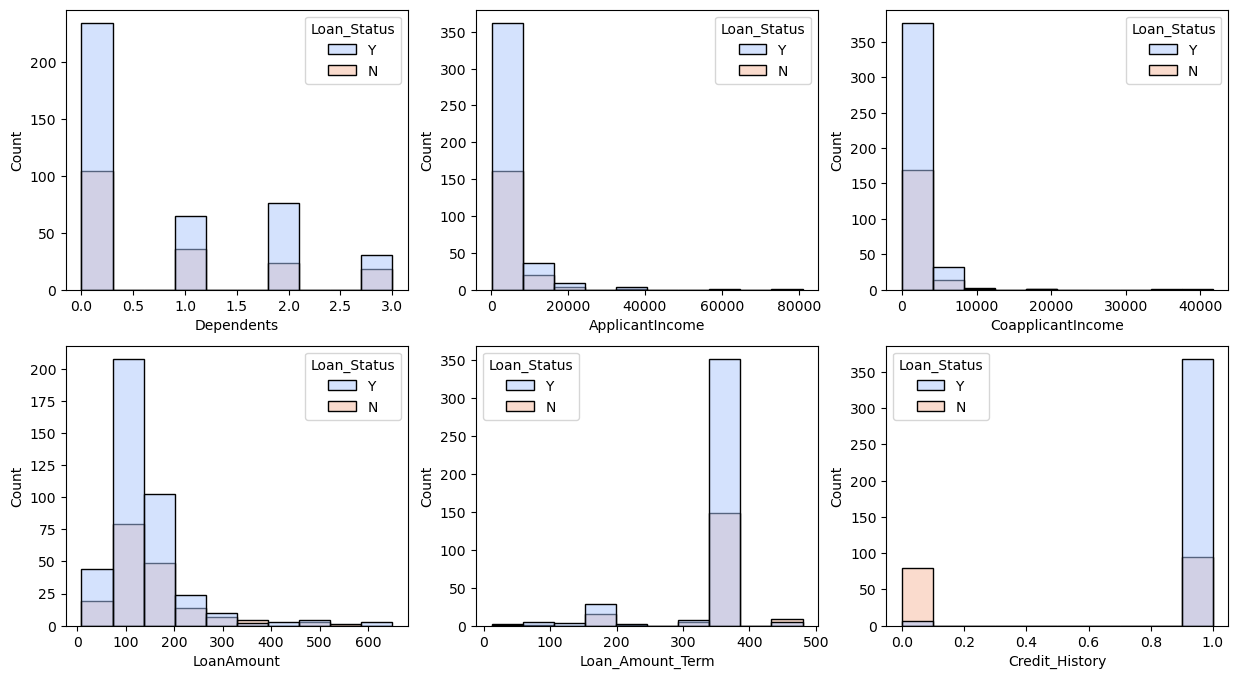

In [75]:
plt.figure(figsize=(15, 8))

for i, obj in enumerate(df.select_dtypes(np.number).columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(x=obj, hue='Loan_Status', data=df, palette='coolwarm', multiple='layer', bins=10)

### Step 4: Feature Engineering

In [52]:
df.drop(['Loan_ID'], axis=1, inplace=True)

In [53]:
object_list = list(df.select_dtypes(np.object_).columns)
num_list = list(df.select_dtypes(np.number).columns)

In [55]:
scaler = StandardScaler()

In [78]:
for col in num_list:
    df[col] = scaler.fit_transform(df[[col]])

In [83]:
le = LabelEncoder()

In [84]:
for col in object_list:
    df[col] = le.fit_transform(df[col])

In [86]:
df.dropna(inplace=True)

<Axes: >

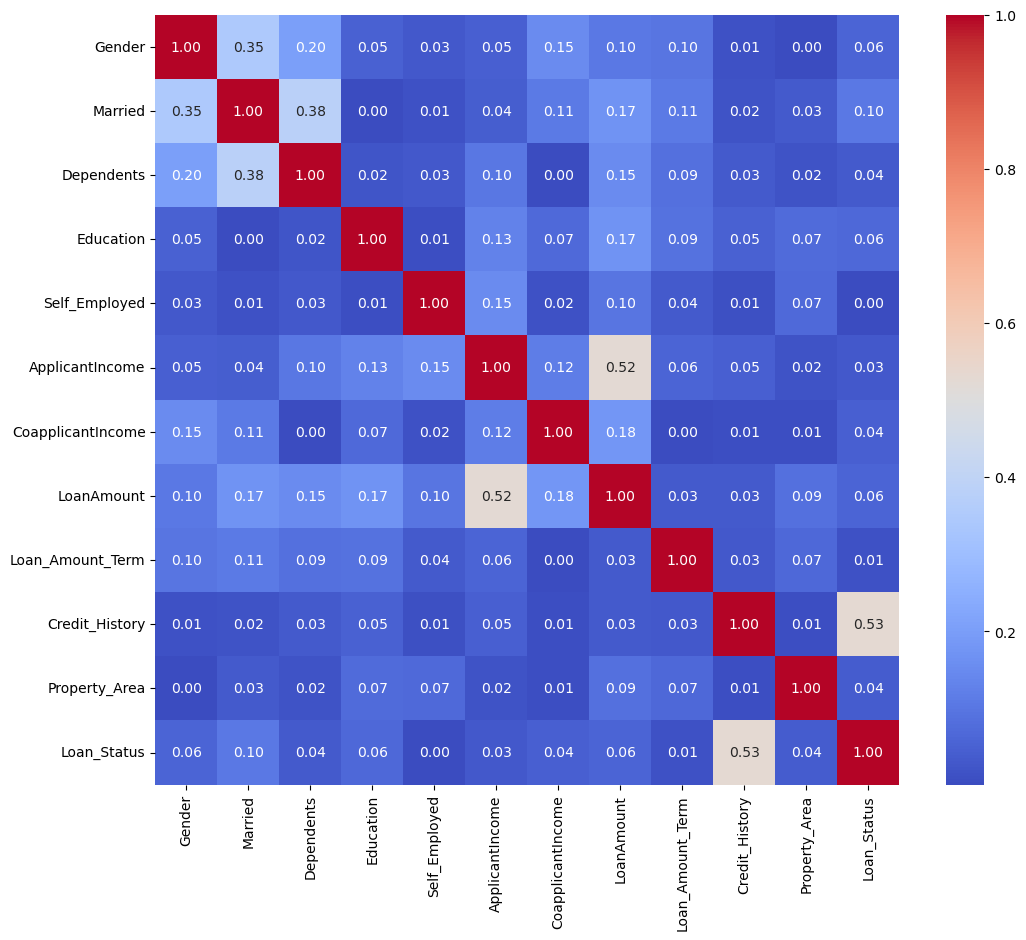

In [91]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr().abs(),
    cmap=plt.cm.coolwarm,
    fmt='.2f',
    annot=True
)

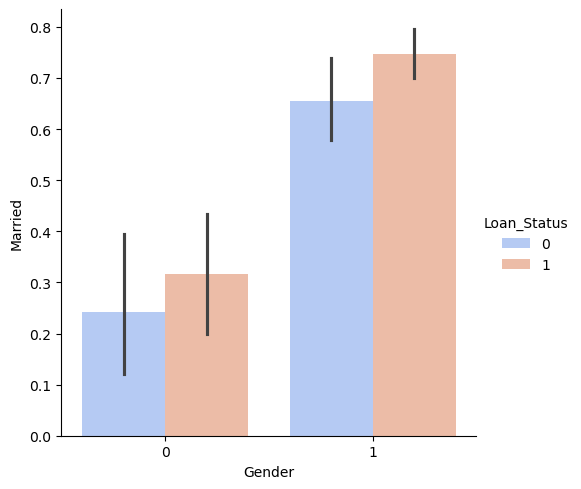

In [108]:
_ = sns.catplot(
    x='Gender',
    y='Married',
    hue='Loan_Status',
    kind='bar',
    data=df,
    palette='coolwarm'
)

### Step 5: Preparing Data

In [111]:
features = df.drop(['Loan_Status'], axis=1)
target = df['Loan_Status']

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Building & Training Model

In [115]:
models = [
    KNeighborsClassifier(n_neighbors=3),
    RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=42),
    SVC(),
    LogisticRegression()
]

In [116]:
for model in models:
    model.fit(X_train, y_train)

### Step 7: Evaluate Model

In [120]:
for model in models:
    y_pred = model.predict(X_test)
    print('Accuracy score of', model.__class__.__name__, ':', round(100 * metrics.accuracy_score(y_test, y_pred), 2), '%')

Accuracy score of KNeighborsClassifier : 81.19 %
Accuracy score of RandomForestClassifier : 79.21 %
Accuracy score of SVC : 87.13 %
Accuracy score of LogisticRegression : 89.11 %
